In [ ]:
import os
import getpass
from dotenv import load_dotenv

load_dotenv()
from langchain_chroma import Chroma
from langchain_google_genai import GoogleGenerativeAIEmbeddings
from langchain.tools import tool
from langchain.chat_models import init_chat_model
from langchain_core.messages import HumanMessage, AIMessage, SystemMessage, ToolMessage
from typing import TypedDict, Optional, List
from typing_extensions import NotRequired
from langchain_core.documents import Document
from langgraph.graph import MessagesState, StateGraph, START, END
import operator
from typing import Annotated
from typing import List, Literal, Optional
from pydantic import BaseModel, Field
from langgraph.types import interrupt, Command, RetryPolicy
from typing import cast
from langgraph.types import Command
from langgraph.graph import END
from langchain_core.messages import HumanMessage, AIMessage, AnyMessage

def format_chat_history(messages) -> str:
    """
    Produce a human-readable transcript like:
    User: ...
    Assistant: ...
    Tool: ...
    """

    lines = []
    for msg in messages:
        if isinstance(msg, HumanMessage):
            lines.append(f"User: {msg.content}")
        elif isinstance(msg, AIMessage):
            lines.append(f"Assistant: {msg.content}")
        elif isinstance(msg, SystemMessage):
            lines.append(f"System: {msg.content}")
        elif isinstance(msg, ToolMessage):
            tool_name = msg.additional_kwargs.get("tool_name", "tool")
            lines.append(f"Tool[{tool_name}]: {msg.content}")
        else:
            # fallback for unknown message types
            role = getattr(msg, "role", "unknown")
            lines.append(f"{role.capitalize()}: {msg.content}")

    return "\n".join(lines)


if not os.environ.get("GOOGLE_API_KEY"):
    os.environ["GOOGLE_API_KEY"] = getpass.getpass("Enter API key for Google Gemini: ")

model = init_chat_model(
    "google_genai:gemini-2.5-flash",
    temperature=0
)
embeddings = GoogleGenerativeAIEmbeddings(model="models/gemini-embedding-001")

# Vector store
vector_store = Chroma(
    collection_name="whitepapers",
    embedding_function=embeddings,
    persist_directory="./chroma_langchain_db",
)

# similar_docs = vector_store.similarity_search("What is observability?", k=2)
# similar_docs
from langchain.tools import tool, ToolRuntime

@tool
def rag_context_retriever(query, runtime: ToolRuntime) -> str:
    """Retrieve relevant documents from the vector store based on the query.
    Args:
        query (str): The input query string.
    Returns:
        Formatted Context.
    """
    # vector_store.similarity_search_with_relevance_scores(query, k=k)
    k = 5
    context_with_metadata = vector_store.similarity_search(query, k=k)
    contexts = [doc.page_content for doc in context_with_metadata]
    # runtime.state["retrieved_contexts"] = contexts

    contexts = runtime.state["retrieved_contexts"] ## Accumulate contexts in state for reviewer contexts
    formatted_contexts = "\n---\n".join(contexts)
    print(f"Retrieved {len(contexts)} contexts for the query: '{query}'")

    return formatted_contexts

# Augment the LLM with tools
tools = [rag_context_retriever]
tools_by_name = {tool.name: tool for tool in tools}
model_with_tools = model.bind_tools(tools)
# model_with_tools.invoke("Use the tool to gather context and answer based on it.\nUSER QUERY: What is observability")

In [13]:
model_with_tools.invoke("Use the tool to gather context and answer based on it.\nUSER QUERY: What is observability")

AIMessage(content='', additional_kwargs={'function_call': {'name': 'rag_context_retriever', 'arguments': '{"query": "What is observability"}'}, '__gemini_function_call_thought_signatures__': {'5530e747-0f77-42a8-9bb3-5fc997a335b7': 'CskCAXLI2nyBUqMRYL1quo9Um0STzGiJprg/dKQM20vIIdEMuVdoAvPK97uw9X2AM6qeM2qeYOleHNQ+qEC23TDMgZikeTf1sk7N32yAwFlJhvZZDekcgaymacuQhTa7+4iy6QZHp2pDjQn8a68K9dqkNLpHIqzPwJxi2C+F24VpoXQhUeTytYiBZECmFvjvmqVGnHmZ9VYV3zD8xxBbx9jriPlYrB/0wm4h3fKzEpzRzw9gJ+wGQcLJVLsZ3kpGQ1TijGQZOHbQSmmesRjFmndl2iR2Dk/Xz5Hujdzps3eMg0WoOwx4VSu4VwrCJkbXGq07OdHiPKsIykJ3MORyigmlSgNFjJC6u7JzkyhBo64sy8ReCediAvLpeJ2Y9L6GG2XzpyB5VlxkCNuL3SGD25EJwzaygOmKRMEOi+ROjmB1P+uJq/w4dnBT4mA='}}, response_metadata={'prompt_feedback': {'block_reason': 0, 'safety_ratings': []}, 'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019b2974-f717-78b3-bfef-cce0e7bfe5ed-0', tool_calls=[{'name': 'rag_context_retriever', 'args': {'query': 'Wha

In [64]:
rag_context_retriever("What is observability?")

AttributeError: 'NoneType' object has no attribute 'state'

In [2]:
class AgentState(MessagesState):
    # Core query info
    user_query: str                         # original user input
    rewritten_query: NotRequired[str]       # from QueryAnalyzer, if available

    # # Conversation / agent messages (optional but recommended for agents)
    rag_messages: NotRequired[
        Annotated[List[AnyMessage], operator.add]
    ]

    # Retrieval-related
    retrieved_contexts: NotRequired[Annotated[List[Document], operator.add]]  # raw retrieved docs or chunks


    # Clarification control
    clarification_counter: int = 0          # to cap number of clarification turns
    clarification_counter_limit: int = 3
    query_analyzer_reasoning: NotRequired[str]
    query_analyzer_intent: NotRequired[str]
    query_analyzer_confidence: NotRequired[float]

    # Final answer from the agent
    final_response: NotRequired[str]

    # Evaluation / QA
    is_good_answer: NotRequired[str]
    reviewer_reason: NotRequired[str]


class QueryAnalysis(BaseModel):
    """Structured output for the Query Analyzer node."""
    # Optional rewritten / normalized query
    rewritten_query: Optional[str] = Field(
        default=None,
        description="A clarified, normalized version of the user query. Only provided when safe to rewrite.",
    )

    # Clarification decision
    needs_clarification: bool = Field(
        ...,
        description="Whether the system must ask a clarification question before proceeding.",
    )

    # Optional clarification questions
    clarification_questions: Optional[List[str]] = Field(
        default=None,
        description="Clarification questions to ask the user if needs_clarification is True.",
    )

    # Optional reasoning fields
    rationale: Optional[str] = Field(
        default=None,
        description="Explanation for reasoning, rewrite choice, and clarification decision.",
    )

    intent: Literal[
        "information_retrieval",
        "greetings_or_generic",
    ] = Field(
        default="greetings_or_generic",
        description="High-level intent classification of the query.",
    )

    confidence: float = Field(
        default=0.0,
        ge=0.0,
        le=1.0,
        description="Model's confidence (0–1) in its analysis.",
    )

model_with_structured_output = model.with_structured_output(QueryAnalysis)




# model_with_structured_output.invoke("Analyze the following user query and provide structured output according to the QueryAnalysis schema.\nUSER QUERY: What is observability")



class AnswerAnalysis(BaseModel):
    """Structured output for the Answer node."""
    
    # Evaluation / QA
    is_good_answer: str = Field(
        ...,
        description="Indicates whether the answer is satisfactory ('yes' or 'no')."
    )
    
    reviewer_reason: str = Field(
        ...,
        description="Reasoning behind the evaluation of the answer."
    )

model_with_answer_evaluation = model.with_structured_output(AnswerAnalysis)
# model_with_answer_evaluation.invoke("Evaluate the following answer based on its quality and relevance to the user's query.\nUSER QUERY: What is observability?\nAGENT ANSWER: Observability is a measure of how well the internal states of a system can be inferred from its external outputs. It involves collecting, analyzing, and visualizing data from various sources to gain insights into system performance, reliability, and user experience.")


In [3]:
QUERY_ANALYZER_PROMPT = """You are a Query Analyzer for a retrieval-based assistant.

Your job is to:
1) Decide whether the user’s query needs clarification before proceeding.
2) Optionally rewrite the query into a clearer, retrieval-friendly form.
3) Classify the intent as either:
   - "information_retrieval"
   - "greetings_or_generic"
4) Provide a confidence score between 0 and 1.

You MUST follow these rules when filling the QueryAnalysis schema:

- rewritten_query:
  - Use this to produce a concise, unambiguous version of the user query that is suitable for retrieval (search / RAG).
  - Keep the original meaning; do NOT add constraints or assumptions that the user did not state.
  - If the query is a pure greeting or generic chit-chat, set rewritten_query to null.
  - If the query is too ambiguous and truly cannot be safely rewritten yet, set rewritten_query to null.

- needs_clarification:
  - Set to True only if the system cannot safely act on the query without more information, and a follow-up question is required.
  - Common reasons:
    - Missing key constraints (e.g., timeframe, dataset, document, product, location) that are essential for a meaningful answer.
    - Multiple distinct interpretations or tasks that must be disambiguated.
  - If you set needs_clarification = True:
    - clarification_questions MUST contain one or more short, direct questions.
    - Each question should ask for only one thing.
    - Do NOT rewrite the query; leave rewritten_query as null or a very generic version if needed.

- clarification_questions:
  - Only populate if needs_clarification = True.
  - Ask the minimum number of questions needed to make the query actionable (usually 1–3).
  - Questions must be natural and user-facing, e.g. "Which time period are you interested in?" 

- intent:
  - "information_retrieval":
      The user is asking for information, explanation, comparison, summary, or similar content that can be answered via retrieval or knowledge.
      Examples: "What is observability?", "Summarize the latest 5G whitepaper", "Compare Kafka and Pub/Sub."
  - "greetings_or_generic":
      Greetings, small talk, thanks, or meta-questions about the assistant.
      Examples: "Hi", "Hello", "How are you?", "Thanks!", "Who are you?"

- confidence:
  - 1.0 → very clear, straightforward query and classification.
  - ~0.5 → somewhat ambiguous, but you can still make a reasonable judgment.
  - <0.3 → highly ambiguous or unclear query.

- rationale:
  - Optional short explanation (1–3 sentences) of why you decided on needs_clarification, intent, and (if present) the rewritten_query.

General behavior:
- Be conservative about rewriting: avoid adding details the user did not provide.
- Prefer needs_clarification = False if the query is reasonably understandable and can be answered broadly.
- Do NOT ask clarification if you can reasonably answer the query as-is with a generic interpretation.

Now analyze the following user query and produce a QueryAnalysis object:


CHAT HISTORY:
{chat_history}

USER QUERY:
{user_query}
"""

analysis = model_with_structured_output.invoke(
    QUERY_ANALYZER_PROMPT.format(chat_history="", user_query="What is observability?")
)

analysis.model_dump()

{'rewritten_query': 'What is observability?',
 'needs_clarification': False,
 'clarification_questions': None,
 'rationale': 'The user is directly asking for a definition, which is a clear information retrieval intent.',
 'intent': 'information_retrieval',
 'confidence': 1.0}

### Define Nodes

In [4]:
def query_analyzer_node(state: AgentState) -> Command[AgentState]:
    """Node to analyze and potentially rewrite user queries."""

    # Ensure messages key exists
    messages: list[AnyMessage] = state.get("messages", [])
    chat_history = "\n".join(m.pretty_repr() for m in messages)
    # Append the latest user query as a HumanMessage
    messages.append(HumanMessage(content=state["user_query"]))

    # Call LLM with structured output
    analysis: QueryAnalysis = model_with_structured_output.invoke(
        QUERY_ANALYZER_PROMPT.format(
            chat_history=chat_history,
            user_query=state["user_query"],
        )
    )

    # Default next node
    goto = "retriever"

    # Persist analysis metadata into state (if present)
    if analysis.rationale is not None:
        state["query_analyzer_reasoning"] = analysis.rationale

    if analysis.intent is not None:
        state["query_analyzer_intent"] = analysis.intent

    if analysis.confidence is not None:
        state["query_analyzer_confidence"] = analysis.confidence

    # Clarification logic
    confidence = analysis.confidence or 0.0
    clarification_counter = state.get("clarification_counter", 0)
    clarification_limit = state.get("clarification_counter_limit", 3)

    if (
        analysis.needs_clarification
        and confidence > 0.6
        and analysis.clarification_questions
        and clarification_counter < clarification_limit
    ):
        # Increment clarification counter
        state["clarification_counter"] = clarification_counter + 1

        # Ask the user the clarification question(s)
        final_q = " ".join(analysis.clarification_questions)
        state["final_response"] = final_q
        messages.append(AIMessage(content=final_q))

        # Stop the graph here and return to caller / UI
        return Command(update=state, goto=END)

    # If we have a safe rewritten query, store it and optionally append to messages
    if analysis.rewritten_query:
        state["rewritten_query"] = analysis.rewritten_query
        # Optionally add as a new "normalized" human message
        
        if analysis.rewritten_query.lower() != state["user_query"].lower():
            messages.append(HumanMessage(content=analysis.rewritten_query))

    # Continue to the retriever node
    return Command(update=state, goto=goto)


In [5]:
from langchain_core.messages import AnyMessage

test_query = "What is observability?"

initial_state: AgentState = {
    "user_query": test_query,
    "clarification_counter": 0,
    "clarification_counter_limit": 3,
    "messages": [],  # starting with empty history
}

cmd = query_analyzer_node(initial_state)

print("Goto:", cmd.goto)

# In this design, we used `update=state`, so:
new_state = cmd.update  # this is the full updated state we returned

print("\n=== New State Keys ===")
for k, v in new_state.items():
    print(f"{k}: {v!r}")

print("\n=== Messages ===")
for m in new_state["messages"]:
    print("-", m.type, ":", m.content)

print("\nRewritten query:", new_state.get("rewritten_query"))
print("Analyzer reasoning:", new_state.get("query_analyzer_reasoning"))
print("Intent:", new_state.get("query_analyzer_intent"))
print("Confidence:", new_state.get("query_analyzer_confidence"))
print("Final response (if clarification):", new_state.get("final_response"))


Goto: retriever

=== New State Keys ===
user_query: 'What is observability?'
clarification_counter: 0
clarification_counter_limit: 3
messages: [HumanMessage(content='What is observability?', additional_kwargs={}, response_metadata={})]
query_analyzer_reasoning: 'The user is directly asking for a definition, which is a clear information retrieval task.'
query_analyzer_intent: 'information_retrieval'
query_analyzer_confidence: 1.0
rewritten_query: 'What is observability?'

=== Messages ===
- human : What is observability?

Rewritten query: What is observability?
Analyzer reasoning: The user is directly asking for a definition, which is a clear information retrieval task.
Intent: information_retrieval
Confidence: 1.0
Final response (if clarification): None


In [6]:
# def retriever_node(state: AgentState) -> Command[AgentState]:
#     """Node to retrieve context documents based on the (possibly rewritten) query."""

#     # Determine which query to use
#     query = state.get("rewritten_query") or state["user_query"]

#     # Retrieve relevant documents
#     retrieved_docs = vector_store.similarity_search(query, k=5)

#     # Store retrieved documents in state
#     state["retrieved_context"] = retrieved_docs

#     # Continue to the next node (e.g., answer generation)
#     return Command(update=state, goto="answer_generator")

In [7]:
def generator_node(state: AgentState) -> Command[AgentState]:
    """Node to retrieve context documents based on the (possibly rewritten) query."""

    # Determine which query to use
    query = state.get("rewritten_query") or state["user_query"]

    SYSTEM_PROMPT = """Role:
    You are a Retrieval-Augmented Generation (RAG) assistant. Your primary function is to 
    locate, retrieve, and synthesize information from a document database based on user queries.

Behavior Guidelines:
    1. Understand the Query:
        - Analyze the user's request carefully.
        - Identify key concepts, keywords, and entities to guide retrieval.

    2. Retrieve Documents:
        - Use the `rag_context_retriever` tool to search the document database.
        - Construct effective search queries using the extracted key terms.
        - Retrieve the most relevant documents or passages.

    3. Synthesize the Answer:
        - Read and interpret the retrieved content.
        - Provide a clear, accurate, and comprehensive response strictly based on retrieved documents.
        - Do NOT hallucinate or create information not present in the retrieved context.
        - If retrieved content is insufficient, explicitly state the limitation.

    4. Citation / Traceability:
        - Clearly reference which parts of the response are grounded in the retrieved documents.
        - Maintain transparency about the origin of information when needed.

Output Format:
    - Provide a detailed, well-structured response to the user query.
    - Organize content using headings, bullet points, or paragraphs for clarity.
    - Ensure the answer is grounded in retrieved evidence and is easy to understand.

"""
    # Ensure messages key exists
    messages: list[AnyMessage] = state.get("messages", [])

    # Build chat history from all messages except the last user turn
    # (so the analyzer sees prior context, but not the current query twice)
    chat_history = "\n".join(m.pretty_repr() for m in messages[:-1])
    messages_prompt = [
        {"role": "system", "content": SYSTEM_PROMPT+"\n\nCHAT HISTORY:\n"+chat_history},
        {"role": "user", "content": query},
    ]

    # Retrieve relevant documents
    response = model_with_tools.invoke(messages_prompt+ state["rag_messages"])
    
    

    # Continue to the next node (e.g., answer generation)
    return {"rag_messages": [response], "final_response": response.content}
  

In [8]:
response = model_with_tools.invoke("Use the tool and answer what is observability?")
response

AIMessage(content='', additional_kwargs={'function_call': {'name': 'rag_context_retriever', 'arguments': '{"query": "observability"}'}, '__gemini_function_call_thought_signatures__': {'afd72de8-6660-4b87-98a5-904f5a05bb92': 'CvsBAXLI2nyovmfcyAprrY+9m0T4vrVAzr6tbrJeeruBv5qdd/sMhVxb48KUz2OhEnHXlsOZoP67o/i4vrjdNldmCsfOn8H8JyM/Rd6bzX/CZPEKtIIGoql876obYOtoEvStn5/EEuxI/5jkey1SxQSSfxE1RuhF5j+iDij7XBzOoR54GSJt37iS0ng8E5gXI/+CAzeXSyXThEc53qwTL6KfuTREWdmvi8X/oF7Wdin977D4xFsPogG8UpiEH0G/VKEhHxpBE2WEZz9HAbxWNTiEd4xuyulBPFKSvSxj5ucxafj7+eNS1CtUfU1lTfRlTsH961i9ZNXGEz7ekRs='}}, response_metadata={'prompt_feedback': {'block_reason': 0, 'safety_ratings': []}, 'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019b2943-182c-7901-85c2-c8753a5c31bf-0', tool_calls=[{'name': 'rag_context_retriever', 'args': {'query': 'observability'}, 'id': 'afd72de8-6660-4b87-98a5-904f5a05bb92', 'type': 'tool_call'}], usage_metadata={'input_tokens

In [9]:
from langchain.messages import ToolMessage


def retriever_node(state: AgentState):
    """Performs the tool call"""
    
    result = []
    for tool_call in state["rag_messages"][-1].tool_calls:
        tool = tools_by_name[tool_call["name"]]
        observation = tool.invoke(tool_call["args"])
        result.append(ToolMessage(content=observation, tool_call_id=tool_call["id"]))

    return {"rag_messages": result}

In [10]:
from typing import Literal
from langgraph.graph import StateGraph, START, END


def should_continue(state: AgentState) -> Literal["retriever_node", END]:
    """Decide if we should continue the loop or stop based upon whether the LLM made a tool call"""

    messages = state["rag_messages"]
    last_message = messages[-1] 

    # If the LLM makes a tool call, then perform an action
    if last_message.tool_calls:
        return "retriever_node"

    # Otherwise, we stop (reply to the user)
    return END

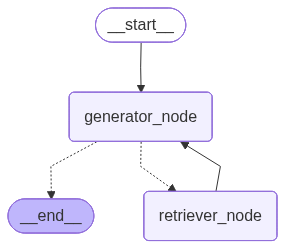

ValidationError: 1 validation error for rag_context_retriever
runtime
  Field required [type=missing, input_value={'query': 'What is observability?'}, input_type=dict]
    For further information visit https://errors.pydantic.dev/2.12/v/missing

In [11]:
# Build workflow
agent_builder = StateGraph(AgentState)

# Add nodes
agent_builder.add_node("generator_node", generator_node)
agent_builder.add_node("retriever_node", retriever_node)

# Add edges to connect nodes
agent_builder.add_edge(START, "generator_node")
agent_builder.add_conditional_edges(
    "generator_node",
    should_continue,
    ["retriever_node", END]
)
agent_builder.add_edge("retriever_node", "generator_node")

# Compile the agent
agent = agent_builder.compile()

# Show the agent
from IPython.display import Image, display
display(Image(agent.get_graph(xray=True).draw_mermaid_png()))

# Invoke
test_query = "What is observability?"

initial_state: AgentState = {
    "user_query": test_query,
    "messages": [],  # starting with empty history
}
output = agent.invoke(initial_state)
output

In [ ]:
def answer_analyser_node(state: AgentState):
    """Node to analyse the final answer from the RAG agent."""

    # Get the final query and answer
    query = state.get("rewritten_query") or state["user_query"]
    answer = state["final_response"]


    SYSTEM_PROMPT = """
    You are an Answer Quality Analyst for a retrieval-based assistant.
    
    Your job is to evaluate the quality of the answer provided by the RAG agent based on the user's query.
    You must provide whether its a good answer or a bad answer, along with reasoning.

    You MUST follow these rules when filling the AnswerQuality schema:
    - is_good_answer:
      - Set to True if the answer is accurate, relevant, and satisfactorily addresses the user's query.
      - Set to False if the answer is incorrect, irrelevant, or fails to address the user's query.
    - reviewer_reason:
        - A brief explanation (1-3 sentences) justifying your assessment.
    Now analyze the following user query and the provided answer:
    USER QUERY:
    {user_query}
    ANSWER:
    {answer}
    """
    analysis: AnswerAnalysis = model_with_answer_evaluation.invoke(
        SYSTEM_PROMPT.format(
            user_query=query,
            answer=answer,
        )
    )

    # Persist analysis metadata into state (if present)
    state["is_good_answer"] = analysis.is_good_answer
    state["reviewer_reason"] = analysis.reviewer_reason

    if state["is_good_answer"].lower() == "yes":
        return Command(update=state, goto=END)
    else:
        return Command(update=state, goto="query_rewriter")

    

In [ ]:
def query_rewriter_node(state: AgentState) -> Command[AgentState]:
    """Node to rewrite the user query for better retrieval."""
    
    # Get the original user query
    user_query = state["user_query"]
    reviewer_reason = state.get("reviewer_reason", "")
    answer = state.get("final_response", "")
    messages: list[AnyMessage] = state.get("messages", [])
    chat_history = "\n".join(m.pretty_repr() for m in messages[:-1])
    retrieved_contexts = state.get("retrieved_contexts", [])
    formatted_contexts = "\n---\n".join([doc.page_content for doc in retrieved_contexts])

    # Prompt to rewrite the query
    REWRITE_PROMPT = """
    You are a Query Rewriter for a retrieval-based assistant.
    
    Your job is to rewrite the user's query to improve retrieval performance.
    
    Guidelines:
    - Maintain the original intent of the user's query.
    - Make the query more specific and unambiguous.
    - Avoid adding information that was not present in the original query.
    - Take a look at the chat history, the user's original query, the reviewer's feedback, the answer provided by the agent, and the retrieved contexts to inform your rewriting.
    
    Now rewrite the following user query, using the below context and reviewer's feedback to guide your rewriting:
    
    CHAT HISTORY:
    {chat_history} 

    USER QUERY:
    {user_query}
    
    REVIEWER REASON:
    {reviewer_reason}   
    
    ANSWER:
    {answer}
    
    RETRIEVED CONTEXTS:
    {formatted_contexts}

    """
    
    rewritten_query: str = model.invoke(
        REWRITE_PROMPT.format(user_query=user_query,
                              reviewer_reason=reviewer_reason,
                              answer=answer,
                              chat_history=chat_history,
                              formatted_contexts=formatted_contexts
                                )
    )

    # Update state with rewritten query
    state["rewritten_query"] = rewritten_query

    # Continue to retriever node
    return Command(update=state, goto="retriever_node")